# Phase 2 — Task 3: Answer the Business with Pandas

## Objective

This notebook uses the cleaned NorthStar Goods order table to answer real
"which / how much / when" questions using idiomatic pandas (groupby, merge,
pivot/melt, and time-series resampling), and proves the Task 2 casing fix
makes the regions merge match every row.

**Input:** `dataset/northstar_clean.csv` (cleaned orders) and
`dataset/northstar_regions.csv` (regions reference table).

In [1]:
# Import pandas for data manipulation and matplotlib for charts.
import pandas as pd
import matplotlib.pyplot as plt

# Show all columns when previewing a DataFrame, instead of truncating.
pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 100

In [2]:
# Load the cleaned orders table, parsing order_date straight into a datetime
# column rather than leaving it as text.
df = pd.read_csv('../../dataset/northstar_clean.csv', parse_dates=['order_date'])

# Load the regions reference table, parsing launch_date as a datetime too.
regions = pd.read_csv('../../dataset/northstar_regions.csv', parse_dates=['launch_date'])

print(f"Orders: {df.shape[0]:,} rows, {df.shape[1]} columns.")
print(f"Regions reference: {regions.shape[0]} rows, {regions.shape[1]} columns.")
df.head()

Orders: 999 rows, 11 columns.
Regions reference: 8 rows, 4 columns.


,order_id,order_date,customer_id,region,product_category,quantity,unit_price,discount_pct,payment_method,total_amount,returned
0,NS-00522,2024-02-23,CUST-0214,West,Toys,7.0,173.91,0,Card,1217.37,N
1,NS-00740,2024-11-23,CUST-0062,London,Food & Drink,1.0,89.36,5,Card,84.89,N
2,NS-00824,2024-08-25,CUST-0264,Scotland,Sports,2.0,8.15,10,Card,14.67,N
3,NS-00663,2024-01-13,CUST-0056,London,Clothing,9.0,178.22,0,Card,1603.98,N
4,NS-00412,2024-03-24,CUST-0169,Midlands,Toys,5.0,28.53,0,PayPal,142.65,Y


In [3]:
# Preview the regions reference table in full (only 8 rows).
regions

,region,regional_manager,country,launch_date
0,North,Sarah Whitfield,England,2019-03-01
1,South,James Bennett,England,2018-06-15
2,East,Priya Sharma,England,2020-01-10
3,West,Daniel Hughes,England,2019-09-05
4,Scotland,Fiona MacLeod,Scotland,2021-02-20
5,Wales,Rhys Davies,Wales,2020-11-01
6,London,Olivia Clarke,England,2017-05-01
7,Midlands,Mohammed Iqbal,England,2018-02-14


## 1. Groupby

### 1a. Total revenue per region

In [4]:
# Sum total_amount for every order in a region, then rank regions by revenue.
revenue_by_region = (
    df.groupby("region")["total_amount"]
    .sum()
    .sort_values(ascending=False)
    .round(2)
)
revenue_by_region

region
North       89670.44
South       84435.95
London      73878.89
East        65605.20
Midlands    57027.34
West        56225.58
Scotland    51617.42
Wales       35158.23
Name: total_amount, dtype: float64

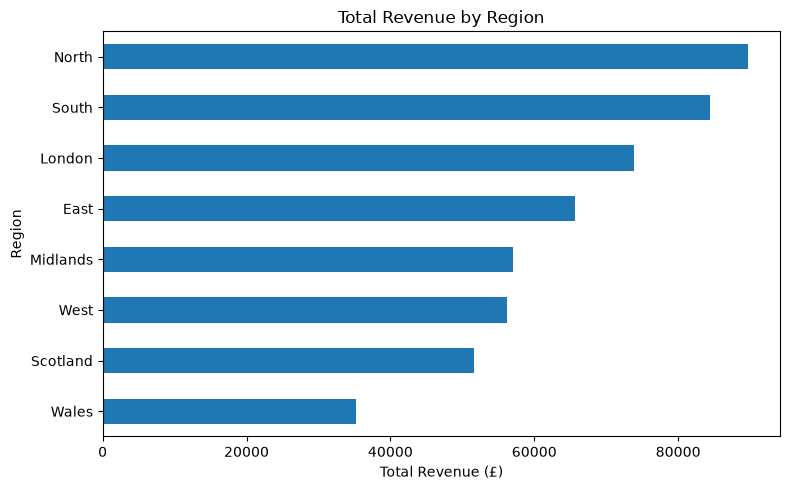

In [5]:
# Horizontal bar chart, sorted smallest to largest so the biggest bar is at
# the top when read top-to-bottom.
fig, ax = plt.subplots(figsize=(8, 5))
revenue_by_region.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Total Revenue by Region")
ax.set_xlabel("Total Revenue (£)")
ax.set_ylabel("Region")
plt.tight_layout()
plt.show()

**Finding:** North generates the most total revenue (£89,670), with the other
regions spread fairly evenly behind it. Wales brings up the rear with
noticeably less revenue (£35,158) than every other region, consistent with it
having the fewest orders in the Task 1 EDA.

### 1b. Average order value per product_category

In [6]:
# Mean total_amount per category, ranked highest to lowest.
avg_order_value_by_category = (
    df.groupby("product_category")["total_amount"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)
avg_order_value_by_category

product_category
Sports           597.55
Electronics      527.38
Food & Drink     522.22
Clothing         502.31
Beauty           498.90
Home & Garden    492.04
Toys             452.60
Name: total_amount, dtype: float64

**Finding:** Sports has the highest average order value (£597.55) despite a
mid-sized order count in Task 1's EDA, while Home & Garden has the highest
order *count* but a below-average order value (£492.04). Volume and value
don't move together here; a category that gets a lot of orders isn't
necessarily the one generating the most revenue per order.

### 1c. Top 5 customers by total spend, with rank

In [7]:
# Sum spend per customer, take the top 5, then attach an explicit rank column
# rather than relying on row position alone.
top_customers = (
    df.groupby("customer_id")["total_amount"]
    .sum()
    .round(2)
    .sort_values(ascending=False)
    .head(5)
    .to_frame("total_spend")
)
top_customers["rank"] = range(1, len(top_customers) + 1)
top_customers

,total_spend,rank
customer_id,,
CUST-0135,6260.59,1
CUST-0296,5866.81,2
CUST-0074,5299.69,3
CUST-0160,5266.72,4
CUST-0001,5226.45,5


**Finding:** the top 5 customers by spend are clearly ahead of the median
customer, but no single customer dominates the business. The gap between
rank 1 (£6,260.59) and rank 5 (£5,226.45) is modest, suggesting revenue isn't
concentrated in a handful of accounts.

### 1d. Revenue per region per month (multi-key groupby)

In [8]:
# Create a Period column at monthly granularity for grouping.
df["order_month"] = df["order_date"].dt.to_period("M")

# Group by two keys at once: region and month.
revenue_region_month = (
    df.groupby(["region", "order_month"])["total_amount"]
    .sum()
    .round(2)
)

# Reshape the multi-index Series into a region x month table for readability.
revenue_region_month.unstack("order_month")

order_month,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12
region,,,,,,,,,,,,
East,3794.15,8677.91,4612.96,6833.26,4641.71,5184.13,6771.54,5701.58,4991.49,2699.70,6013.49,5683.28
London,6670.37,7751.46,3295.16,8437.48,1856.39,3992.27,7405.18,7315.20,8267.56,9263.40,3751.87,5872.55
Midlands,5282.37,6385.01,4957.61,3773.47,4168.76,3384.05,5253.95,5437.95,7086.12,5004.94,2806.69,3486.42
North,8280.12,8983.50,6257.25,6895.70,4778.76,13661.03,2209.10,8942.24,1496.70,13626.32,5724.00,8815.72
Scotland,4018.03,2754.27,3893.81,5183.18,3606.69,5336.04,6134.27,1934.27,2710.52,3674.76,7064.78,5306.80
South,4918.65,4740.64,3935.05,3420.55,11348.11,12498.99,7567.45,6343.02,6191.12,10808.38,4423.07,8240.92
Wales,1329.82,2251.35,2400.25,2699.63,1303.17,1970.08,1833.07,2632.07,5169.13,3204.36,1657.81,8707.49
West,1501.39,9987.52,2281.85,4095.07,2444.81,4501.86,3335.00,7409.13,3934.45,4835.04,5513.24,6386.22


**Finding:** Revenue per region fluctuates month to month with no obvious
single region trending consistently upward or downward across the year. The
variation looks more like normal order-volume noise than a seasonal pattern
tied to any particular region. For the business, this means monthly
regional targets should be set against a rolling average of recent months
rather than a single prior month, since any one month's dip or spike in a
region is unlikely to persist.

### 1e. Per-region summary: unique customers, total orders, mean basket size, return rate

In [9]:
# A single .agg() call with named aggregations, computing summary
# statistics per region in one pass rather than several separate groupbys.
# n_returned is included alongside return_rate so a reader can see how much
# data each rate rests on before treating a high/low rate as meaningful.
region_summary = df.groupby("region").agg(
    unique_customers=("customer_id", "nunique"),
    total_orders=("order_id", "count"),
    mean_basket_size=("quantity", "mean"),
    return_rate=("returned", lambda s: (s == "Y").mean()),
    n_returned=("returned", lambda s: (s == "Y").sum()),
).round(3)

region_summary

,unique_customers,total_orders,mean_basket_size,return_rate,n_returned
region,,,,,
East,102,122,5.533,0.221,27
London,117,143,5.441,0.308,44
Midlands,90,111,5.694,0.225,25
North,134,169,5.793,0.254,43
Scotland,87,95,5.421,0.326,31
South,125,163,5.693,0.221,36
Wales,63,71,5.451,0.183,13
West,105,125,4.904,0.152,19


**Finding:** return rate varies more across regions than mean basket size
does. Scotland is highest at 32.6% (31 of 96 orders) and West is lowest at
15.2% (19 of 125 orders), against an overall rate of 23.8%. With order counts
in this range, the standard error on each region's rate is roughly 3.3-5.1
percentage points, so Scotland and West each sit only about 2 standard
errors from the overall rate, suggestive but not conclusive on their own.
This is worth investigating with a proper test (e.g. a chi-squared test of
return rate by region) rather than treated as a confirmed regional effect.
Mean basket size, by contrast, is fairly stable across regions (4.9 to 5.8
units), so the revenue differences in 1a are driven mainly by order volume
and customer count, not by regions ordering unusually large or small
baskets.

## 2. Merge

Join the orders to the regions reference table to enrich each order with
`regional_manager` and `country`. This is where Task 2's casing normalisation
gets proven, instead of being assumed: if `region` in the orders table didn't exactly
match `region` in the reference table, the merge would silently drop rows.

In [10]:
# Compare the distinct region labels on both sides of the merge before
# actually joining, to sanity check they line up.
print("Distinct regions in orders:", sorted(df["region"].unique()))
print("Distinct regions in reference table:", sorted(regions["region"].unique()))

Distinct regions in orders: ['East', 'London', 'Midlands', 'North', 'Scotland', 'South', 'Wales', 'West']
Distinct regions in reference table: ['East', 'London', 'Midlands', 'North', 'Scotland', 'South', 'Wales', 'West']


### 2a. Inner join

In [11]:
# Inner join: only keeps rows where region matches on both sides. If casing
# didn't line up, unmatched orders would silently disappear here.
orders_inner = df.merge(regions, on="region", how="inner")

print(f"Orders before merge: {len(df)}")
print(f"Orders after inner merge: {len(orders_inner)}")

orders_inner[["order_id", "region", "regional_manager", "country", "total_amount"]].head()

Orders before merge: 999
Orders after inner merge: 999


,order_id,region,regional_manager,country,total_amount
0,NS-00522,West,Daniel Hughes,England,1217.37
1,NS-00740,London,Olivia Clarke,England,84.89
2,NS-00824,Scotland,Fiona MacLeod,Scotland,14.67
3,NS-00663,London,Olivia Clarke,England,1603.98
4,NS-00412,Midlands,Mohammed Iqbal,England,142.65


### 2b. Left join

In [12]:
# Left join: keeps every order regardless of whether region matched, filling
# the joined columns with NaN where it didn't. This is the safer join to
# audit with, since unmatched rows are visible rather than silently dropped.
orders_left = df.merge(regions, on="region", how="left")

print(f"Orders before merge: {len(df)}")
print(f"Orders after left merge: {len(orders_left)}")
print(f"Rows with no matching region (regional_manager is null): "
      f"{orders_left['regional_manager'].isna().sum()}")

orders_left[["order_id", "region", "regional_manager", "country", "total_amount"]].head()

Orders before merge: 999
Orders after left merge: 999
Rows with no matching region (regional_manager is null): 0


,order_id,region,regional_manager,country,total_amount
0,NS-00522,West,Daniel Hughes,England,1217.37
1,NS-00740,London,Olivia Clarke,England,84.89
2,NS-00824,Scotland,Fiona MacLeod,Scotland,14.67
3,NS-00663,London,Olivia Clarke,England,1603.98
4,NS-00412,Midlands,Mohammed Iqbal,England,142.65


### 2c. Proving the join matched every row

In [13]:
# An inner join drops unmatched rows silently; a left join keeps them but
# leaves the joined columns null. Comparing row counts and checking for nulls
# after a left join is how you prove a merge is complete rather than just
# assuming it.
rows_lost_in_inner = len(df) - len(orders_inner)
nulls_after_left = orders_left["regional_manager"].isna().sum()

print(f"Rows lost using an inner join: {rows_lost_in_inner}")
print(f"Rows with unmatched region after a left join: {nulls_after_left}")

# Fail loudly if either check indicates an incomplete merge, rather than
# silently trusting that the join worked.
assert rows_lost_in_inner == 0, "Inner join dropped rows -- casing mismatch present."
assert nulls_after_left == 0, "Left join found unmatched regions -- casing mismatch present."
print()
print("Confirmed: every order matched a region. The inner and left joins produced "
      "identical row counts, which is only possible because Task 2 normalised "
      "region casing to match the reference table exactly.")

Rows lost using an inner join: 0
Rows with unmatched region after a left join: 0

Confirmed: every order matched a region. The inner and left joins produced identical row counts, which is only possible because Task 2 normalised region casing to match the reference table exactly.


**Finding:** the inner and left joins both return all 999 orders with zero
unmatched rows or nulls in `regional_manager`. This directly confirms the
Task 2 region-casing fix worked as intended. Before that fix, the raw data
had 23 raw region labels against 8 in the reference table, and a
case-sensitive merge would have silently dropped every row whose casing
didn't match exactly.

## 3. Reshape

### 3a. Pivot: region (rows) x product_category (columns) = total revenue

In [14]:
# pivot_table reshapes long data into a wide grid: one row per region, one
# column per category, with revenue summed into each cell.
revenue_pivot = df.pivot_table(
    values="total_amount",
    index="region",
    columns="product_category",
    aggfunc="sum",
).round(2)

revenue_pivot

product_category,Beauty,Clothing,Electronics,Food & Drink,Home & Garden,Sports,Toys
region,,,,,,,
East,11035.15,7369.21,7595.36,10734.80,6558.54,12507.11,9805.03
London,12124.69,15922.03,9853.74,7260.59,13074.68,9148.12,6495.04
Midlands,5442.89,7657.06,7168.96,9462.33,11844.39,12993.99,2457.72
North,15772.84,8719.05,24142.08,10048.86,14305.23,6850.21,9832.17
Scotland,6028.34,6540.01,9498.95,7810.16,7294.59,8662.89,5782.48
South,15097.23,11161.99,12624.28,15729.64,9248.57,13832.14,6742.10
Wales,6319.86,5698.97,3727.02,1732.24,5460.01,7032.08,5188.05
West,1518.00,5747.61,8188.50,8765.57,12416.24,12032.41,7557.25


### 3b. Melt back to long format

In [15]:
# melt is the inverse of pivot: it turns the wide grid back into one row
# per (region, category) combination, which is the shape most pandas
# operations and plotting libraries expect.
revenue_long = revenue_pivot.reset_index().melt(
    id_vars="region",
    var_name="product_category",
    value_name="total_revenue",
)

revenue_long.head(10)

,region,product_category,total_revenue
0,East,Beauty,11035.15
1,London,Beauty,12124.69
2,Midlands,Beauty,5442.89
3,North,Beauty,15772.84
4,Scotland,Beauty,6028.34
5,South,Beauty,15097.23
6,Wales,Beauty,6319.86
7,West,Beauty,1518.00
8,East,Clothing,7369.21
9,London,Clothing,15922.03


In [16]:
# Compare shapes to make the wide vs long difference concrete.
print(f"Pivoted (wide) shape: {revenue_pivot.shape}")
print(f"Melted (long) shape: {revenue_long.shape}")

Pivoted (wide) shape: (8, 7)
Melted (long) shape: (56, 3)


**When to use each shape:** the wide (pivoted) form is better for a human
reader scanning a region-by-category grid or feeding a heatmap, while the
long (melted) form is better for further pandas processing, such as
filtering, grouping, or feeding into a plotting library that expects one row
per observation (e.g. seaborn/plotly) rather than one column per category.

## 4. Time Series

In [17]:
# Set order_date as the index and sort chronologically. Required before
# resampling or rolling calculations will behave correctly.
ts = df.set_index("order_date").sort_index()
ts.head()

,order_id,customer_id,region,product_category,quantity,unit_price,discount_pct,payment_method,total_amount,returned,order_month
order_date,,,,,,,,,,,
2024-01-02,NS-00846,CUST-0186,Scotland,Beauty,2.0,102.65,0,PayPal,205.30,N,2024-01
2024-01-02,NS-00845,CUST-0223,North,Beauty,9.0,191.90,0,Card,1727.10,Y,2024-01
2024-01-02,NS-00901,CUST-0161,Scotland,Home & Garden,10.0,30.38,0,PayPal,303.80,N,2024-01
2024-01-02,NS-00381,CUST-0295,East,Sports,2.0,58.78,5,Card,111.68,N,2024-01
2024-01-02,NS-00773,CUST-0109,Scotland,Clothing,5.0,136.78,0,Card,683.90,Y,2024-01


### 4a. Resample to monthly revenue and plot

In [18]:
# Resample from order-level rows to one total per calendar month.
# "ME" means month end frequency.
monthly_revenue = ts["total_amount"].resample("ME").sum()
monthly_revenue

order_date
2024-01-31    35794.90
2024-02-29    51531.66
2024-03-31    31633.94
2024-04-30    41338.34
2024-05-31    34148.40
2024-06-30    50528.45
2024-07-31    40509.56
2024-08-31    45715.46
2024-09-30    39847.09
2024-10-31    53116.90
2024-11-30    36954.95
2024-12-31    52499.40
Freq: ME, Name: total_amount, dtype: float64

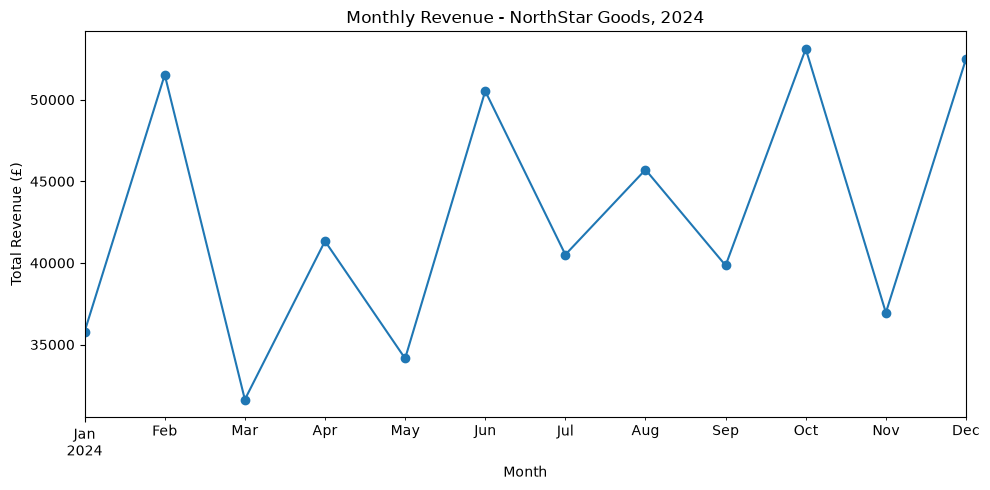

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
monthly_revenue.plot(ax=ax, marker="o")
ax.set_title("Monthly Revenue - NorthStar Goods, 2024")
ax.set_xlabel("Month")
ax.set_ylabel("Total Revenue (£)")
plt.tight_layout()
plt.show()

### 4b. 7-day rolling mean of daily revenue, overlaid on daily revenue

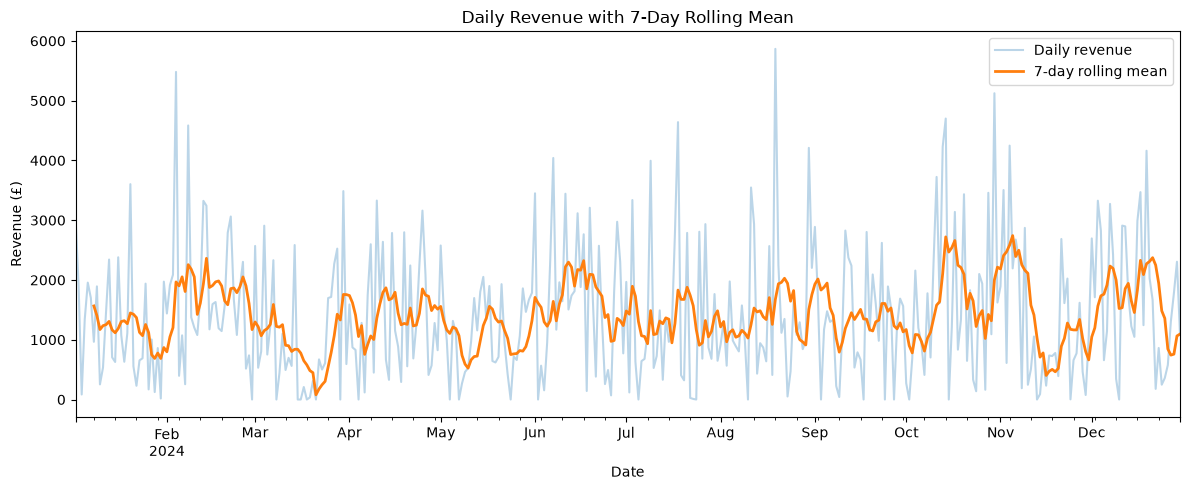

In [20]:
# Resample to daily totals first (much noisier than monthly), then compute
# a 7-day rolling mean to smooth out day-to-day noise and reveal the trend.
daily_revenue = ts["total_amount"].resample("D").sum()
rolling_7d = daily_revenue.rolling(window=7).mean()

fig, ax = plt.subplots(figsize=(12, 5))
daily_revenue.plot(ax=ax, alpha=0.3, label="Daily revenue")
rolling_7d.plot(ax=ax, linewidth=2, label="7-day rolling mean")
ax.set_title("Daily Revenue with 7-Day Rolling Mean")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue (£)")
ax.legend()
plt.tight_layout()
plt.show()

**Finding:** daily revenue is noisy, as expected for order-level data, but
the 7-day rolling mean smooths that out and shows the underlying trend is
roughly flat across the year rather than clearly trending up or down.

### 4c. Month-over-month % change, and the worst month

In [21]:
# pct_change() computes the percentage difference from the prior period;
# the first month is NaN since there's nothing before it to compare to.
mom_pct_change = monthly_revenue.pct_change().mul(100).round(2)

mom_table = pd.DataFrame({
    "revenue": monthly_revenue.round(2),
    "mom_pct_change": mom_pct_change,
})
mom_table

,revenue,mom_pct_change
order_date,,
2024-01-31,35794.90,NaN
2024-02-29,51531.66,43.96
2024-03-31,31633.94,-38.61
2024-04-30,41338.34,30.68
2024-05-31,34148.40,-17.39
2024-06-30,50528.45,47.97
2024-07-31,40509.56,-19.83
2024-08-31,45715.46,12.85
2024-09-30,39847.09,-12.84


In [22]:
# idxmin() on the % change series returns the month with the largest drop.
worst_month = mom_pct_change.idxmin()
worst_month_change = mom_pct_change.min()

print(f"Worst month-over-month change: {worst_month.strftime('%B %Y')} "
      f"({worst_month_change:+.2f}%)")

Worst month-over-month change: March 2024 (-38.61%)


**Finding:** month-over-month revenue swings between roughly +48% and -39%
throughout the year, so the series is genuinely volatile rather than trending
smoothly. March 2024 is the single worst month at -38.6%, following a sharp
+44% jump in February. This points to order-level noise (a handful of large
or small orders moving the monthly total) rather than a seasonal or
structural cause worth investigating further.